# Smartphone Usage 
### Handling Missing Values, Duplicates & Outliers

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("smartphoneusage.csv")

In [2]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN05469,U05469,23.0,Female,7.44,4.36,1.86,4.53,5.42,213.0,123.0,8.15,Low,Yes,Moderate,1
1,TXN00485,U00485,26.0,Male,6.01,4.93,3.03,0.74,7.83,157.0,60.0,6.91,Low,No,Moderate,1
2,TXN00862,U00862,20.0,Other,7.81,1.83,2.07,3.86,5.91,178.0,29.0,9.67,Low,No,Moderate,1
3,TXN05602,U05602,28.0,Male,6.11,1.84,3.00,1.89,6.67,204.0,86.0,7.11,High,Yes,Moderate,1
4,TXN03537,U03537,22.0,Male,6.21,5.36,3.52,3.68,5.27,130.0,45.0,6.73,High,No,Severe,1


In [3]:
print(df.shape)
df.info()

(7612, 16)
<class 'pandas.DataFrame'>
RangeIndex: 7612 entries, 0 to 7611
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7612 non-null   str    
 1   user_id                  7612 non-null   str    
 2   age                      7460 non-null   float64
 3   gender                   7498 non-null   str    
 4   daily_screen_time_hours  7612 non-null   float64
 5   social_media_hours       7612 non-null   float64
 6   gaming_hours             7612 non-null   float64
 7   work_study_hours         7612 non-null   float64
 8   sleep_hours              7383 non-null   float64
 9   notifications_per_day    7536 non-null   float64
 10  app_opens_per_day        7612 non-null   float64
 11  weekend_screen_time      7612 non-null   float64
 12  stress_level             7457 non-null   str    
 13  academic_work_impact     7612 non-null   str    
 14  addiction_level         

In [4]:
df.describe(include='all')


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
count,7612,7612,7460.000000,7498,7612.000000,7612.000000,7612.000000,7612.000000,7383.000000,7536.000000,7612.000000,7612.000000,7457,7612,7612,7612.000000
unique,7500,7500,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,3,NaN
top,TXN07065,U07065,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,No,Moderate,NaN
freq,2,2,NaN,2565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2546,3817,2925,NaN
mean,NaN,NaN,26.620509,NaN,7.519080,3.273702,2.013682,3.240029,6.749387,134.107617,97.766684,9.243297,NaN,NaN,NaN,0.708092
std,NaN,NaN,5.796716,NaN,2.690781,1.584145,1.145158,1.600743,1.352171,66.524100,48.397323,2.716074,NaN,NaN,NaN,0.454670
min,NaN,NaN,-5.000000,NaN,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,22.000000,NaN,5.230000,1.920000,1.020000,1.850000,5.640000,76.000000,55.000000,6.960000,NaN,NaN,NaN,0.000000
50%,NaN,NaN,27.000000,NaN,7.535000,3.270000,2.040000,3.230000,6.730000,134.000000,98.000000,9.260000,NaN,NaN,NaN,1.000000
75%,NaN,NaN,31.000000,NaN,9.820000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.530000,NaN,NaN,NaN,1.000000


##  Correlation Heatmap 

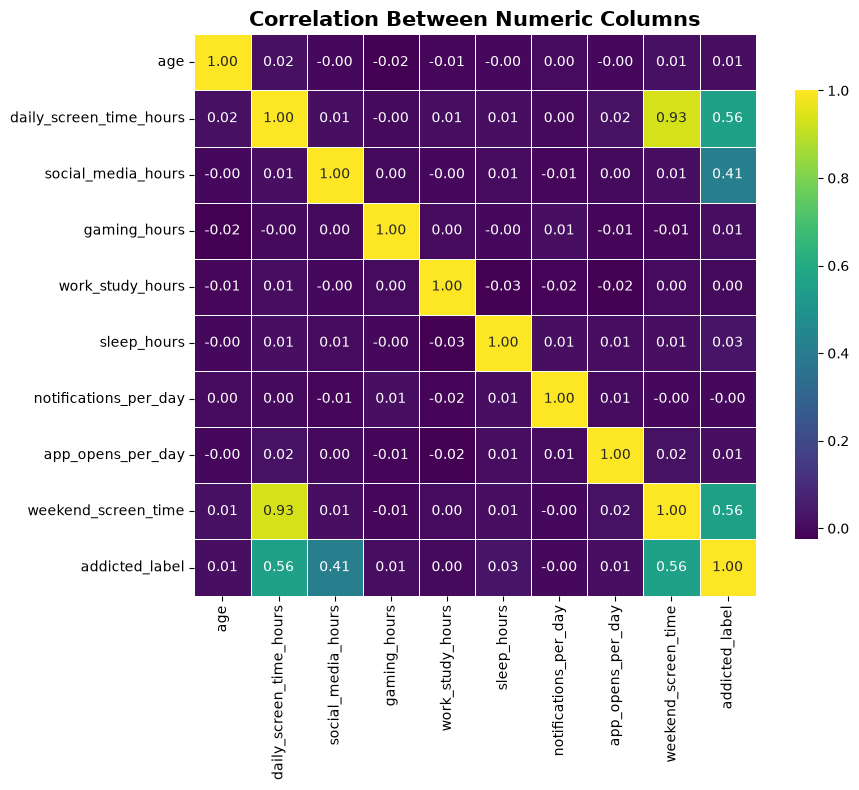

In [5]:
corr_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Between Numeric Columns", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

In [6]:
print(df.isnull().sum())

transaction_id               0
user_id                      0
age                        152
gender                     114
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                229
notifications_per_day       76
app_opens_per_day            0
weekend_screen_time          0
stress_level               155
academic_work_impact         0
addiction_level              0
addicted_label               0
dtype: int64


### HANDLE NULL VALUES

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median(),inplace=True)

# Fill Categorical Columns with Mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())    

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64


C:\Users\Sigma\AppData\Local\Temp\ipykernel_40720\2673951603.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(df[col].median(),inplace=True)
C:\Users\Sigma\AppData\Local\Temp\ipykernel_40720\2673951603.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained ass

In [8]:
df["age"] = df["age"].astype(int)
df["notifications_per_day"] = df["notifications_per_day"].astype(int)
df["app_opens_per_day"] = df["app_opens_per_day"].astype(int)
df["academic_work_impact"] = df["academic_work_impact"].map({"Yes": True, "No": False}).astype(bool)

### HANDLE DUPLICATES

In [9]:
print(df.duplicated().sum())

108


In [10]:
df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())


Duplicates After: 0


### HANDLE OUTLIERS USING IQR and Boxplots — Before vs After Cleaning 

In [11]:

cols_with_outliers = []
for c in numeric_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    if df[(df[c] < lower) | (df[c] > upper)].shape[0] > 0:
        cols_with_outliers.append(c)


print(cols_with_outliers)        


['age', 'daily_screen_time_hours', 'sleep_hours']


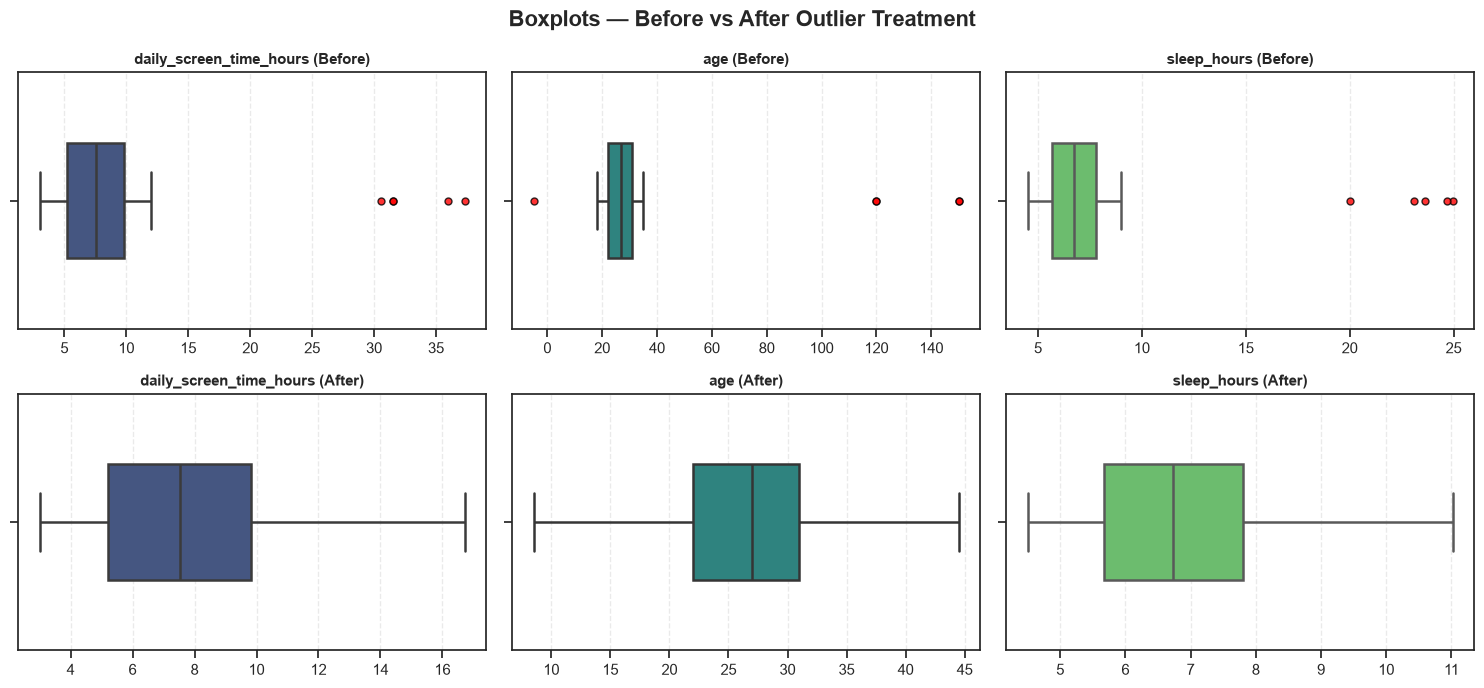

In [12]:

focus_cols = ["daily_screen_time_hours", "age", "sleep_hours"]

df_clean = df.copy()
viridis3 = sns.color_palette("viridis", len(focus_cols))

sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, len(focus_cols), figsize=(15, 7))

for i, col in enumerate(focus_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[0, i],
        color=viridis3[i],
        width=0.45,
        linewidth=1.8,
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='black',
            markersize=5,
            alpha=0.8
        )
    )

    axes[0, i].set_title(f"{col} (Before)", fontsize=11, weight="bold")
    axes[0, i].set_xlabel("")

# CLEANING 
for col in focus_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

for i, col in enumerate(focus_cols):
    sns.boxplot(
        x=df_clean[col],
        ax=axes[1, i],
        color=viridis3[i],
        width=0.45,
        linewidth=1.8,
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='black',
            markersize=5,
            alpha=0.8
        )
    )

    axes[1, i].set_title(f"{col} (After)", fontsize=11, weight="bold")
    axes[1, i].set_xlabel("")

for ax in axes.flatten():
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Boxplots — Before vs After Outlier Treatment", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

In [13]:
for col in cols_with_outliers:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

##  Feature Engineering 

In [14]:
df_fe = df.copy()

df_fe['total_entertainment_hours'] = df_fe['social_media_hours'] + df_fe['gaming_hours']
df_fe['sleep_deficit'] = 8 - df_fe['sleep_hours']
df_fe['screen_time_category'] = pd.cut(df_fe['daily_screen_time_hours'], bins=3,
                                        labels=['Low', 'Medium', 'High'])

df_fe[['total_entertainment_hours', 'sleep_deficit', 'screen_time_category']].head()

,total_entertainment_hours,sleep_deficit,screen_time_category
0,6.22,2.58,Low
1,7.96,0.17,Low
2,3.90,2.09,Medium
3,4.84,1.33,Low
4,8.88,2.73,Low


### Age Group Feature — Turning `age` Into a Story

A raw age number doesn't mean much on its own — but grouping people into life stages (**Teen, Young Adult, Adult, Senior**) turns it into something an instructor or reader can immediately relate to. This new engineered feature lets us ask a clear question:

> **Which age group is most at risk of smartphone addiction?**


In [15]:
# Feature Engineering: bucket age into life-stage groups
age_bins = [0, 19, 25, 40, 120]
age_labels = ['Teen (≤19)', 'Young Adult (20-25)', 'Adult (26-40)', 'Senior (40+)']

df_fe['age_group'] = pd.cut(df_fe['age'], bins=age_bins, labels=age_labels)

df_fe[['age', 'age_group']].head()


,age,age_group
0,23.0,Young Adult (20-25)
1,26.0,Adult (26-40)
2,20.0,Young Adult (20-25)
3,28.0,Adult (26-40)
4,22.0,Young Adult (20-25)


In [16]:
# Addiction risk (%) per age group — the number behind the story
risk_by_age = (df_fe.groupby('age_group', observed=True)['addicted_label']
               .mean().mul(100).round(1)
               .reindex(age_labels))

risk_by_age


age_group
Teen (≤19)              69.1
Young Adult (20-25)     70.9
Adult (26-40)           71.0
Senior (40+)           100.0
Name: addicted_label, dtype: float64

### Composite Risk Score — One Number That Tells the Whole Story

Instead of looking at screen time, sleep, notifications, and stress separately, we combine them into a single weighted **Risk Score (0–100)**. This is the kind of feature that makes a project feel like a real product, not just a school exercise — one number your instructor can immediately grasp, backed by the behaviors underneath it.


In [17]:
# Composite Risk Score — weighted blend of addiction-adjacent behaviors
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_fe['stress_numeric'] = df_fe['stress_level'].map(stress_map)

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

risk_score = (
    0.30 * normalize(df_fe['daily_screen_time_hours']) +
    0.25 * normalize(df_fe['sleep_deficit']) +
    0.20 * normalize(df_fe['notifications_per_day']) +
    0.15 * normalize(df_fe['stress_numeric']) +
    0.10 * normalize(df_fe['app_opens_per_day'])
)

df_fe['risk_score'] = (risk_score * 100).round(1)
df_fe['risk_level'] = pd.qcut(df_fe['risk_score'], q=3, labels=['Low Risk', 'Medium Risk', 'High Risk'])

df_fe[['daily_screen_time_hours', 'sleep_deficit', 'notifications_per_day',
       'stress_numeric', 'app_opens_per_day', 'risk_score', 'risk_level']].head()


,daily_screen_time_hours,sleep_deficit,notifications_per_day,stress_numeric,app_opens_per_day,risk_score,risk_level
0,7.44,2.58,213,0,123,54.5,High Risk
1,6.01,0.17,157,0,60,33.5,Low Risk
2,7.81,2.09,178,0,29,44.7,Medium Risk
3,6.11,1.33,204,2,86,58.8,High Risk
4,6.21,2.73,130,2,45,55.4,High Risk


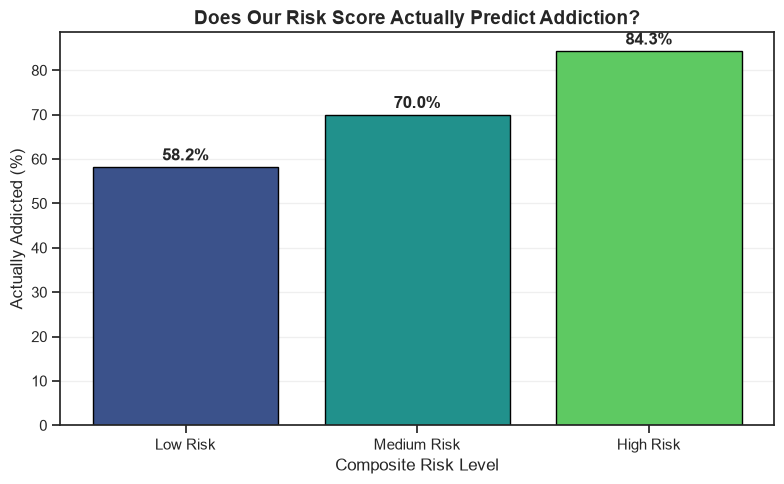

In [18]:
# Validate: does the composite risk score actually line up with real addiction outcomes?
validation = (df_fe.groupby('risk_level', observed=True)['addicted_label']
              .mean().mul(100).round(1)
              .reindex(['Low Risk', 'Medium Risk', 'High Risk']))

plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", len(validation))
bars = plt.bar(validation.index, validation.values, color=colors, edgecolor="black")

for bar, val in zip(bars, validation.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val}%",
              ha="center", fontweight="bold")

plt.title("Does Our Risk Score Actually Predict Addiction?", fontsize=14, fontweight="bold")
plt.xlabel("Composite Risk Level")
plt.ylabel("Actually Addicted (%)")
plt.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()


In [19]:
df.to_csv("smartphone_cleaned.csv", index=False, encoding="utf-8-sig")

##  Visualizations — Bar, Scatter, Hist, KDE & Pie 

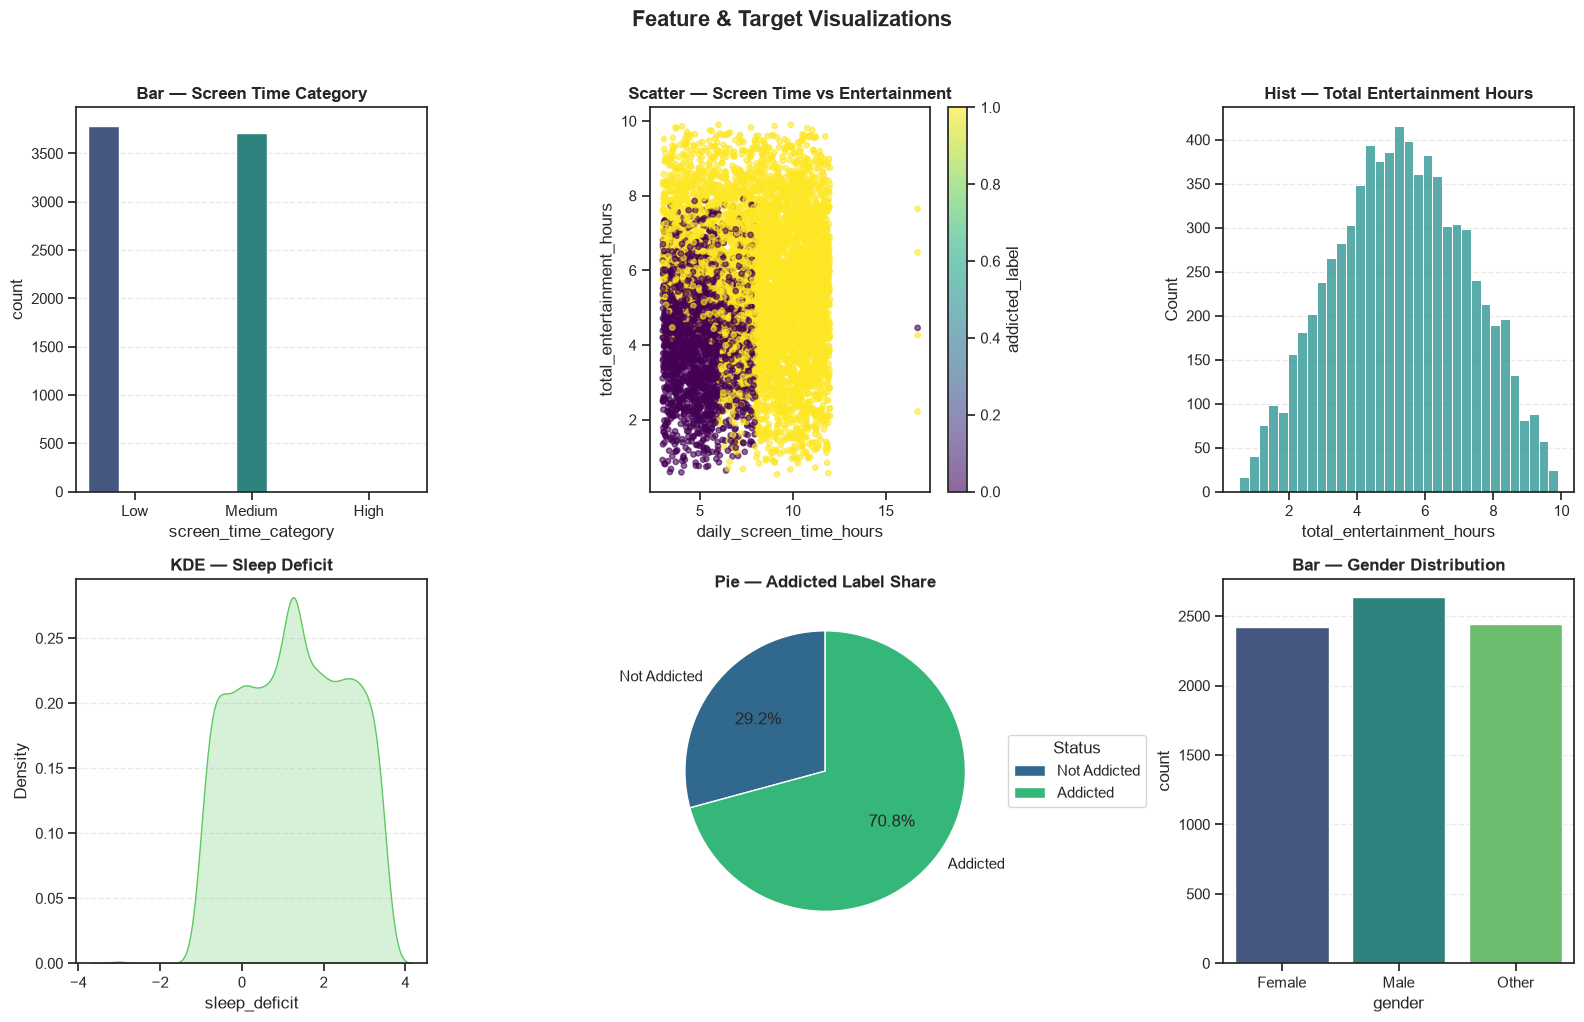

In [20]:
sns.set_theme(style="ticks")
viridis_cat = sns.color_palette("viridis", 3)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Bar - screen time category counts
sns.countplot(x='screen_time_category', data=df_fe, hue='screen_time_category',
              palette="viridis", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Bar — Screen Time Category", weight="bold")

# Scatter - screen time vs entertainment, colored by addiction label
sc = axes[0, 1].scatter(df_fe['daily_screen_time_hours'], df_fe['total_entertainment_hours'],
                         c=df_fe['addicted_label'], cmap="viridis", alpha=0.6, s=15)
axes[0, 1].set_title("Scatter — Screen Time vs Entertainment", weight="bold")
axes[0, 1].set_xlabel("daily_screen_time_hours")
axes[0, 1].set_ylabel("total_entertainment_hours")
plt.colorbar(sc, ax=axes[0, 1], label="addicted_label")

# Hist - total entertainment hours
sns.histplot(df_fe['total_entertainment_hours'], kde=False, color=viridis_cat[1], ax=axes[0, 2])
axes[0, 2].set_title("Hist — Total Entertainment Hours", weight="bold")

# KDE - sleep deficit
sns.kdeplot(df_fe['sleep_deficit'], fill=True, color=viridis_cat[2], ax=axes[1, 0])
axes[1, 0].set_title("KDE — Sleep Deficit", weight="bold")

# Pie - addicted label proportion
label_counts = df_fe['addicted_label'].value_counts().sort_index()

wedges, texts, autotexts = axes[1, 1].pie(
    label_counts,
    labels=['Not Addicted', 'Addicted'],
    autopct='%1.1f%%',
    colors=sns.color_palette("viridis", len(label_counts)),
    startangle=90
)

axes[1, 1].legend(
    wedges,
    ['Not Addicted', 'Addicted'],
    title="Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

axes[1, 1].set_title("Pie — Addicted Label Share", weight="bold")

# Bar - gender counts
sns.countplot(x='gender', data=df_fe, hue='gender', palette="viridis", legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Bar — Gender Distribution", weight="bold")

for ax in [axes[0, 0], axes[0, 2], axes[1, 0], axes[1, 2]]:
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Feature & Target Visualizations", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

###  Visualization — Addiction Risk by Age Group

This is the headline chart for the storytelling angle: it shows, in one glance, how the **percentage of addicted users changes across life stages**.


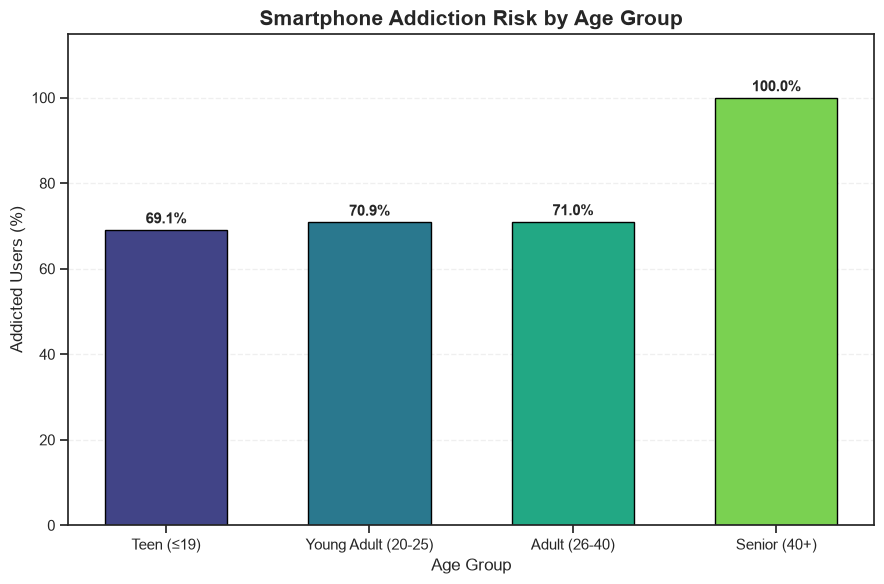

In [21]:
plt.figure(figsize=(9, 6))

colors = sns.color_palette("viridis", len(risk_by_age))
bars = plt.bar(risk_by_age.index.astype(str), risk_by_age.values,
               color=colors, edgecolor="black", width=0.6)

for bar, val in zip(bars, risk_by_age.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val}%",
              ha="center", fontweight="bold", fontsize=11)

plt.title("Smartphone Addiction Risk by Age Group", fontsize=15, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Addicted Users (%)")
plt.ylim(0, max(risk_by_age.values) + 15)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Age × Gender Heatmap — Where Risk Really Concentrates

Looking at age alone can hide interaction effects. This heatmap shows addiction risk broken down by **both age group and gender at once** — often the real story is in the combination, not either factor on its own.


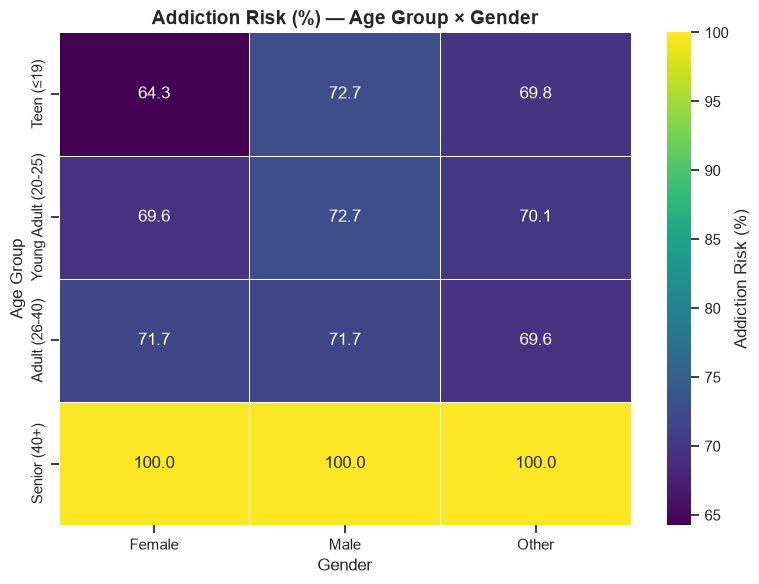

In [22]:
# Addiction risk (%) by Age Group x Gender
pivot = (df_fe.pivot_table(index='age_group', columns='gender', values='addicted_label',
                            aggfunc='mean', observed=True)
         .reindex(age_labels) * 100)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis",
            cbar_kws={'label': 'Addiction Risk (%)'}, linewidths=0.5, linecolor='white')

plt.title("Addiction Risk (%) — Age Group × Gender", fontsize=14, fontweight="bold")
plt.ylabel("Age Group")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()


##  One-Hot Encoding


In [23]:
model_df = df_fe.drop(columns=['transaction_id', 'user_id', 'addiction_level', 'stress_numeric'])

categorical_cols_fe = ['gender', 'stress_level', 'academic_work_impact', 'screen_time_category', 'age_group', 'risk_level']

model_df = pd.get_dummies(model_df, columns=categorical_cols_fe, drop_first=True)

print(model_df.shape)
model_df.head()


(7504, 25)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,...,stress_level_Low,stress_level_Medium,academic_work_impact_True,screen_time_category_Medium,screen_time_category_High,age_group_Young Adult (20-25),age_group_Adult (26-40),age_group_Senior (40+),risk_level_Medium Risk,risk_level_High Risk
0,23.0,7.44,4.36,1.86,4.53,5.42,213,123,8.15,1,...,True,False,True,False,False,True,False,False,False,True
1,26.0,6.01,4.93,3.03,0.74,7.83,157,60,6.91,1,...,True,False,False,False,False,False,True,False,False,False
2,20.0,7.81,1.83,2.07,3.86,5.91,178,29,9.67,1,...,True,False,False,True,False,True,False,False,True,False
3,28.0,6.11,1.84,3.00,1.89,6.67,204,86,7.11,1,...,False,False,True,False,False,False,True,False,False,True
4,22.0,6.21,5.36,3.52,3.68,5.27,130,45,6.73,1,...,False,False,False,False,False,True,False,False,False,True


##  Train/Test Split & Scaling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = model_df.drop(columns=['addicted_label'])
y = model_df['addicted_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




## Model Training — Random Forest, KNN, Decision Tree

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.920720,0.954677,0.932203,0.943306
KNN,0.876749,0.923671,0.900188,0.911779
Decision Tree,0.929380,0.936929,0.965160,0.950835


##  Accuracy Graphs — Cross-Validation & Train vs Test

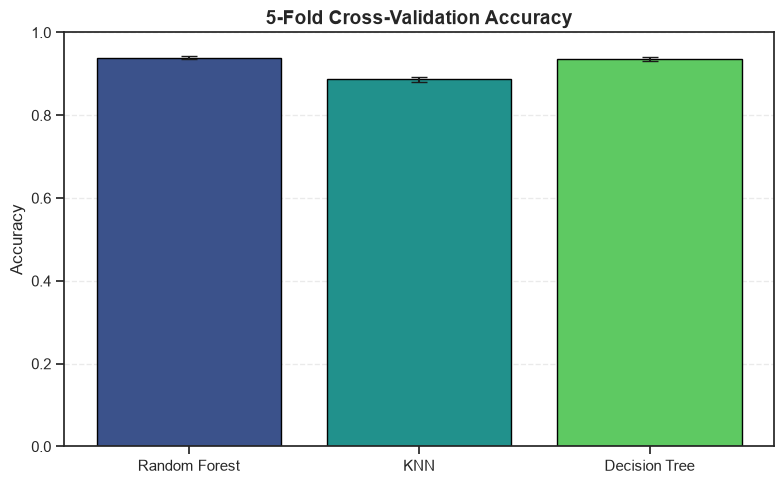

In [26]:
from sklearn.model_selection import cross_val_score

cv_means, cv_stds = {}, {}
for name, model in models.items():
    Xc = X_train_scaled if name == "KNN" else X_train
    scores = cross_val_score(model, Xc, y_train, cv=5, scoring='accuracy')
    cv_means[name] = scores.mean()
    cv_stds[name] = scores.std()

viridis_models = sns.color_palette("viridis", n_colors=len(models))

plt.figure(figsize=(8, 5))
plt.bar(cv_means.keys(), cv_means.values(), yerr=list(cv_stds.values()),
        color=viridis_models, capsize=6, edgecolor="black")
plt.title("5-Fold Cross-Validation Accuracy", fontsize=14, weight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

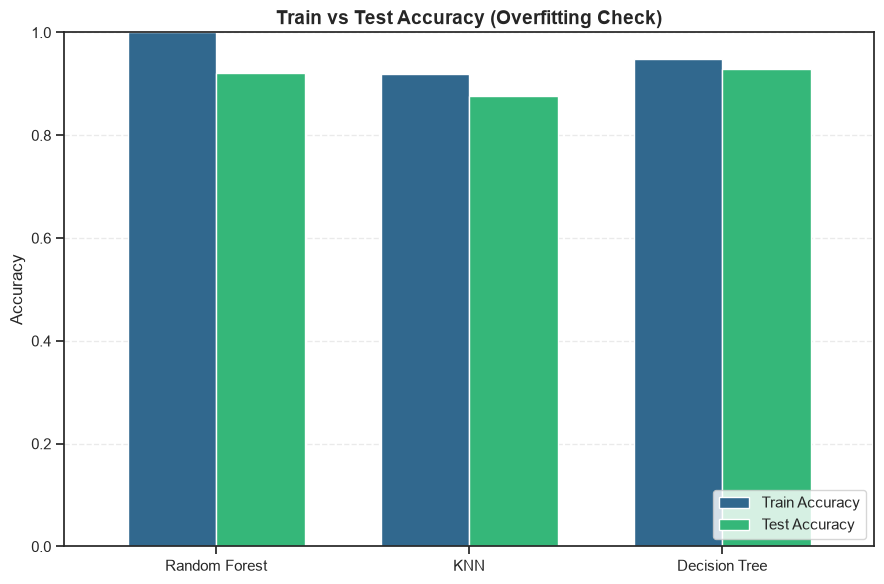

In [27]:
train_acc, test_acc = {}, {}
for name, model in models.items():
    Xtr = X_train_scaled if name == "KNN" else X_train
    Xte = X_test_scaled if name == "KNN" else X_test
    train_acc[name] = accuracy_score(y_train, model.predict(Xtr))
    test_acc[name] = accuracy_score(y_test, model.predict(Xte))

acc_compare_df = pd.DataFrame({"Train Accuracy": train_acc, "Test Accuracy": test_acc})
acc_colors = sns.color_palette("viridis", n_colors=2)

acc_compare_df.plot(kind='bar', figsize=(9, 6), color=acc_colors, width=0.7)
plt.title("Train vs Test Accuracy (Overfitting Check)", fontsize=14, weight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  Model Comparison — Metrics

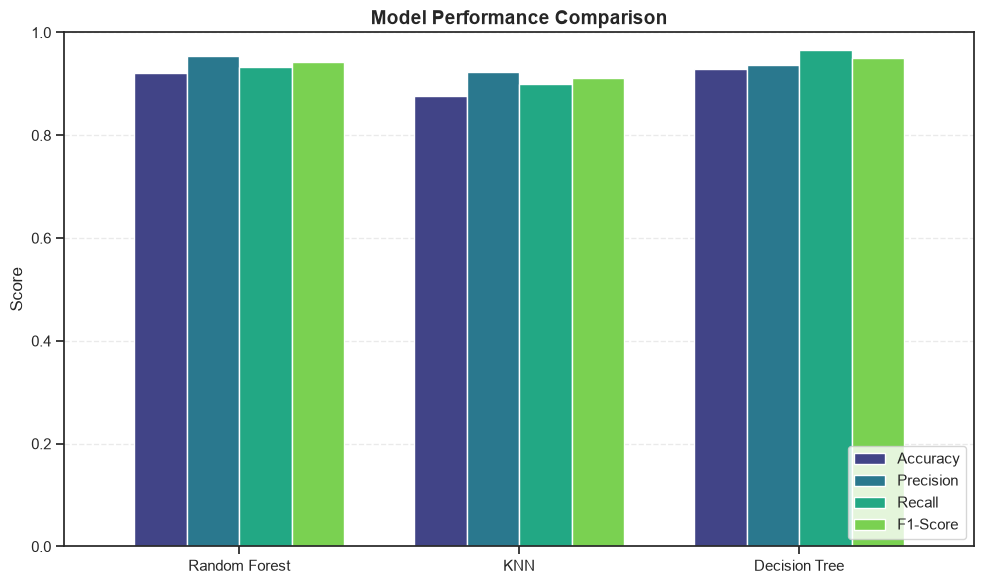

In [28]:
sns.set_theme(style="ticks")
metric_colors = sns.color_palette("viridis", n_colors=len(results_df.columns))

ax = results_df.plot(kind='bar', figsize=(10, 6), color=metric_colors, width=0.75)
plt.title("Model Performance Comparison", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  Confusion Matrices

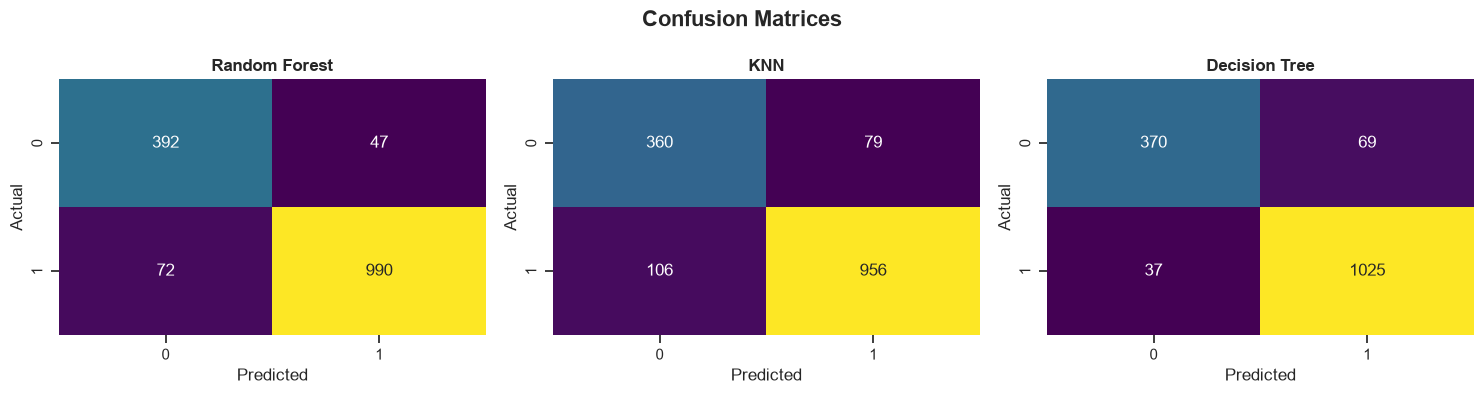

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="viridis", ax=ax, cbar=False)
    ax.set_title(name, fontsize=12, weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

## Feature Importance — Random Forest vs Decision Tree

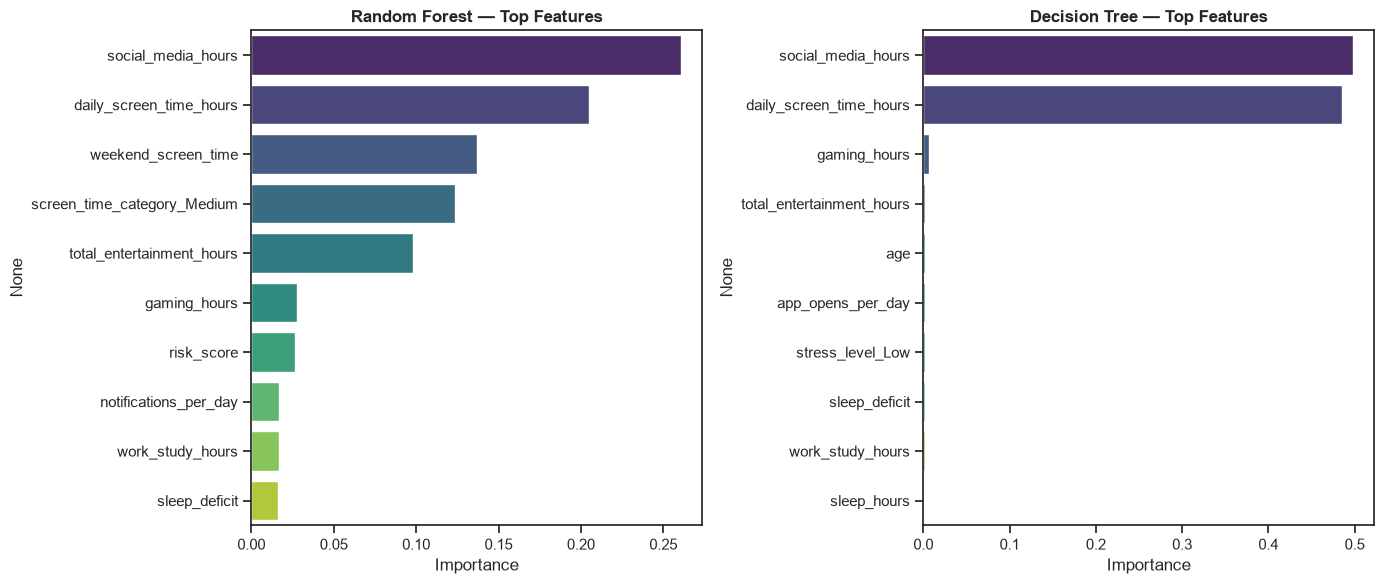

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance = pd.Series(models["Random Forest"].feature_importances_, index=X.columns)\
    .sort_values(ascending=False).head(10)
dt_importance = pd.Series(models["Decision Tree"].feature_importances_, index=X.columns)\
    .sort_values(ascending=False).head(10)

sns.barplot(x=rf_importance.values, y=rf_importance.index, hue=rf_importance.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Random Forest — Top Features", weight="bold")
axes[0].set_xlabel("Importance")

sns.barplot(x=dt_importance.values, y=dt_importance.index, hue=dt_importance.index,
            palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Decision Tree — Top Features", weight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Top Risk Drivers — Plain-English Explainer

This translates the Random Forest's raw feature importances into a clean, presentation-ready ranking — the single best slide to answer *"why does the model think someone is addicted?"*


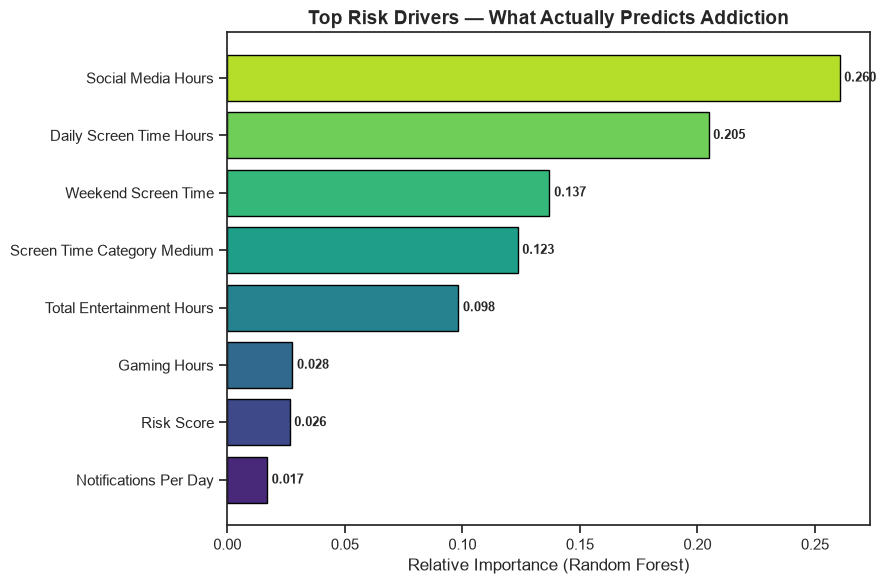

In [31]:
# Plain-English "Top Risk Drivers" chart, built from the Random Forest importances above
def humanize(col):
    return col.replace('_', ' ').title()

top_drivers = rf_importance.head(8).sort_values()
labels = [humanize(c) for c in top_drivers.index]

plt.figure(figsize=(9, 6))
colors = sns.color_palette("viridis", len(top_drivers))
bars = plt.barh(labels, top_drivers.values, color=colors, edgecolor="black")

for bar, val in zip(bars, top_drivers.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
              va="center", fontsize=9, fontweight="bold")

plt.title("Top Risk Drivers — What Actually Predicts Addiction", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance (Random Forest)")
plt.tight_layout()
plt.show()


## SQL QUERIES


In [32]:
import pyodbc


conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.\SQLEXPRESS01;'  
    'DATABASE=nti;' 
    'Trusted_Connection=yes;'  
)


cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")  
for row in cursor:
    print(row)


conn.close()


<>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\Sigma\AppData\Local\Temp\ipykernel_40720\3606205481.py:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=.\SQLEXPRESS01;'


InterfaceError: ('28000', '[28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Login failed for user \'DESKTOP-4ADTLCL\\Sigma\'. (18456) (SQLDriverConnect); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Cannot open database "nti" requested by the login. The login failed. (4060); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Login failed for user \'DESKTOP-4ADTLCL\\Sigma\'. (18456); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Cannot open database "nti" requested by the login. The login failed. (4060)')

In [ ]:


def connect_to_sql_server():
    try:
        
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=.\SQLEXPRESS01;'  
            'DATABASE=nti;'  
            'Trusted_Connection=yes;'  
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None


def read_data_from_sql(conn, query):
    if conn:
        
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None


def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")


if __name__ == "__main__":
    
    conn = connect_to_sql_server()
    
    
    query = """
        SELECT *
        FROM smart;
        """  
    
    
    df = read_data_from_sql(conn, query)
    
    if df is not None:
       
       print(df.head())   
    else:
        print("not found")
    
   
    close_connection(conn)


  transaction_id user_id   age  gender  daily_screen_time_hours  \
0       TXN05469  U05469  23.0  Female                     7.44   
1       TXN00485  U00485  26.0    Male                     6.01   
2       TXN00862  U00862  20.0   Other                     7.81   
3       TXN05602  U05602  28.0    Male                     6.11   
4       TXN03537  U03537  22.0    Male                     6.21   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                4.36          1.86              4.53         5.42   
1                4.93          3.03              0.74         7.83   
2                1.83          2.07              3.86         5.91   
3                1.84          3.00              1.89         6.67   
4                5.36          3.52              3.68         5.27   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    213                123                 8.15          Low   
1             

C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## 1. Average Screen Time by Addiction Level

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT addiction_level,
ROUND(AVG(daily_screen_time_hours),2) AS AvgScreenTime
FROM smart
GROUP BY addiction_level
ORDER BY AvgScreenTime DESC;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  addiction_level  AvgScreenTime
0          Severe           8.60
1        Moderate           8.36
2            Mild           5.16
تم إغلاق الاتصال بنجاح.


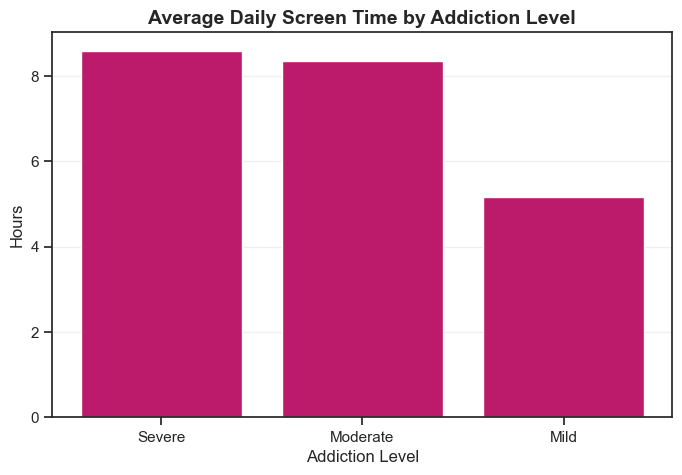

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["addiction_level"], df["AvgScreenTime"],
        color="#BC1A6B")

plt.title("Average Daily Screen Time by Addiction Level",fontsize=14,fontweight='bold')
plt.xlabel("Addiction Level")
plt.ylabel("Hours")
plt.grid(axis='y',alpha=.3)
plt.show()

## 2. Average Sleep Hours by Addiction Level

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT addiction_level,
ROUND(AVG(sleep_hours),2) AS AvgSleep
FROM smart
GROUP BY addiction_level;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  addiction_level  AvgSleep
0            Mild      6.67
1          Severe      6.78
2        Moderate      6.76
تم إغلاق الاتصال بنجاح.


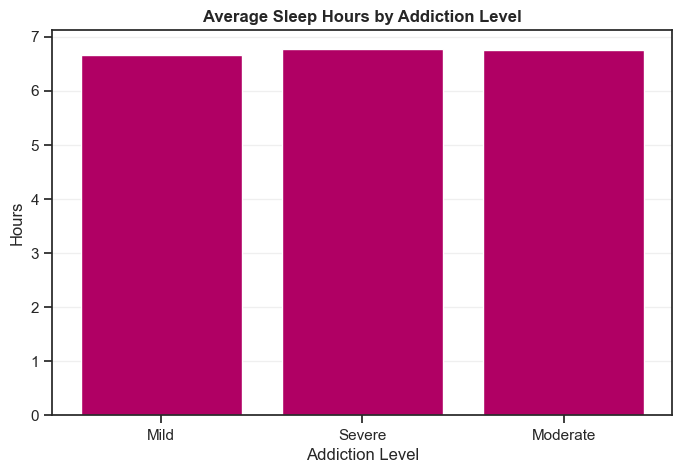

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["addiction_level"], df["AvgSleep"],
        color="#B00064FF")

plt.title("Average Sleep Hours by Addiction Level",fontweight='bold')
plt.xlabel("Addiction Level")
plt.ylabel("Hours")
plt.grid(axis='y',alpha=.3)
plt.show()

## 3. Top 10 Screen Time Users

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT TOP 10
user_id,
daily_screen_time_hours
FROM smart
ORDER BY daily_screen_time_hours DESC;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

  user_id  daily_screen_time_hours
0  U07138                16.719999
1  U00888                16.719999
2  U04928                16.719999
3  U04101                16.719999
4  U02622                16.719999
5  U02237                12.000000
6  U00694                12.000000
7  U05173                12.000000
8  U05236                12.000000
9  U03736                11.990000
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


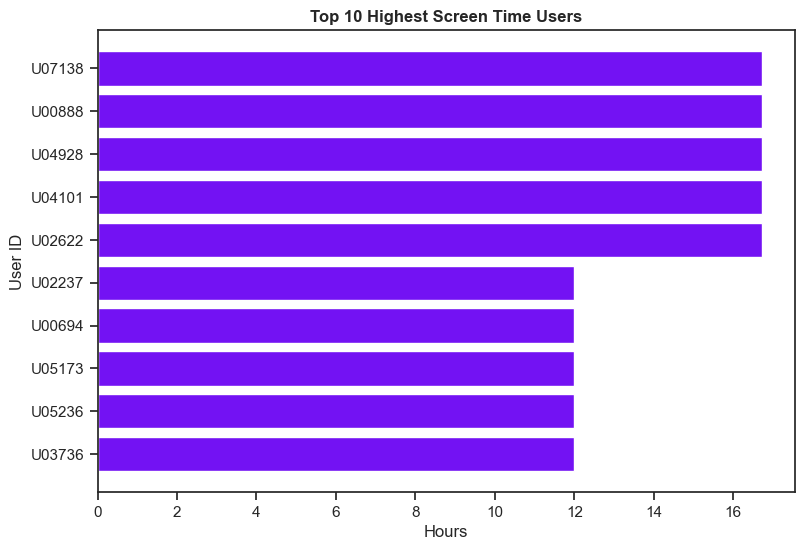

In [ ]:
plt.figure(figsize=(9,6))
plt.barh(df["user_id"].astype(str),
        df["daily_screen_time_hours"],
         color="#7312F3")

plt.title("Top 10 Highest Screen Time Users",fontweight='bold')
plt.xlabel("Hours")
plt.ylabel("User ID")
plt.gca().invert_yaxis()
plt.show()

## 4. Average Social Media Hours by Gender

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT gender,
ROUND(AVG(social_media_hours),2) AS AvgSocial
FROM smart
GROUP BY gender;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

   gender  AvgSocial
0    Male       3.30
1  Female       3.26
2   Other       3.25
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


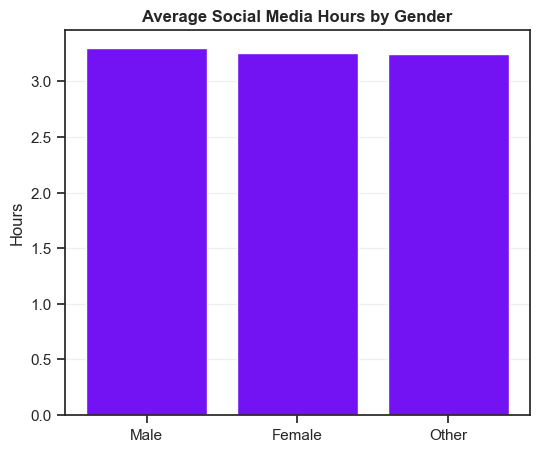

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(df["gender"],
        df["AvgSocial"],
        color="#7312F3")

plt.title("Average Social Media Hours by Gender",fontweight='bold')
plt.ylabel("Hours")
plt.grid(axis='y',alpha=.3)
plt.show()

## 5. Average Screen Time by Age Group

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT
age,
ROUND(AVG(daily_screen_time_hours),2) AS AvgScreenTime
FROM smart
GROUP BY age
ORDER BY age;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

     age  AvgScreenTime
0    8.5           4.20
1   18.0           7.39
2   19.0           7.45
3   20.0           7.40
4   21.0           7.68
5   22.0           7.54
6   23.0           7.41
7   24.0           7.44
8   25.0           7.37
9   26.0           7.70
10  27.0           7.44
11  28.0           7.57
12  29.0           7.61
13  30.0           7.28
14  31.0           7.59
15  32.0           7.51
16  33.0           7.50
17  34.0           7.48
18  35.0           7.75
19  44.5           8.00
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


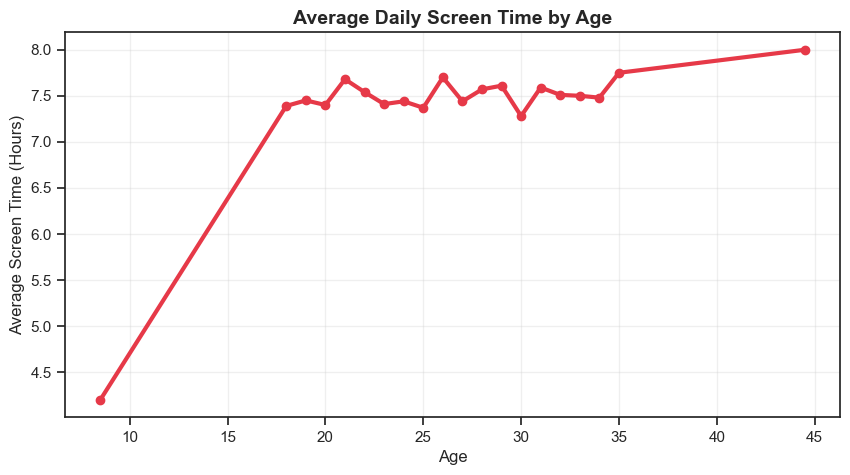

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["age"],
         df["AvgScreenTime"],
         marker='o',
         linewidth=3,
         color="#E63948")

plt.title("Average Daily Screen Time by Age", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(alpha=0.3)

plt.show()

## 6. Average Notifications per Day

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT addiction_level,
ROUND(AVG(notifications_per_day),2) AS AvgNotifications
FROM smart
GROUP BY addiction_level;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

  addiction_level  AvgNotifications
0            Mild               134
1          Severe               132
2        Moderate               135
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


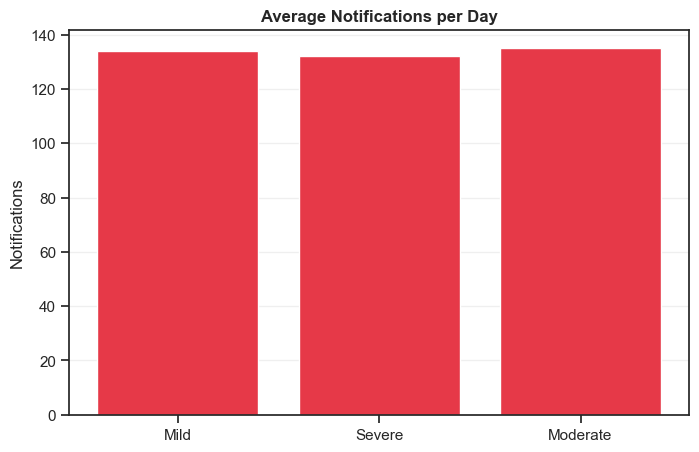

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["addiction_level"],
        df["AvgNotifications"],
        color="#E63948")

plt.title("Average Notifications per Day",fontweight='bold')
plt.ylabel("Notifications")
plt.grid(axis='y',alpha=.3)
plt.show()

## 7. Average Gaming Hours by Age

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT age,
ROUND(AVG(gaming_hours),2) AS AvgGaming
FROM smart
GROUP BY age
ORDER BY age;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

     age  AvgGaming
0    8.5       1.67
1   18.0       1.99
2   19.0       2.07
3   20.0       2.12
4   21.0       2.08
5   22.0       1.99
6   23.0       2.00
7   24.0       2.00
8   25.0       1.99
9   26.0       2.04
10  27.0       2.05
11  28.0       2.08
12  29.0       1.99
13  30.0       2.02
14  31.0       1.98
15  32.0       2.00
16  33.0       1.97
17  34.0       1.94
18  35.0       1.93
19  44.5       2.09
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


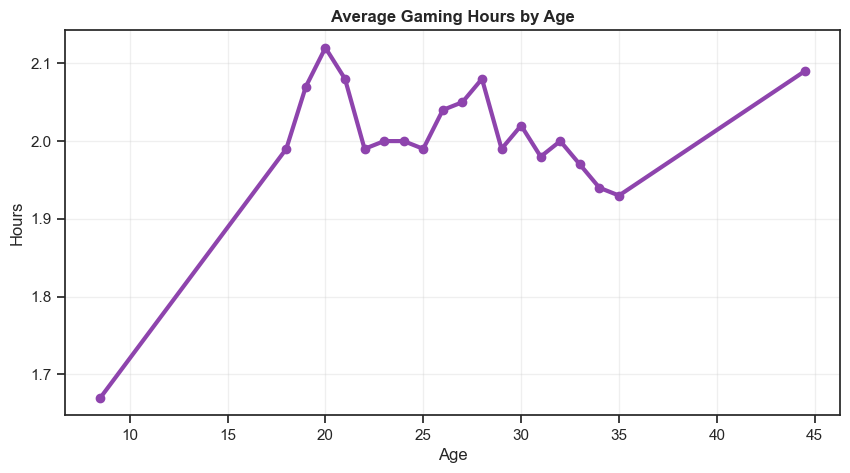

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df["age"],
         df["AvgGaming"],
         marker='o',
         linewidth=3,
         color="#8E44AD")

plt.title("Average Gaming Hours by Age",fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Hours")
plt.grid(alpha=.3)
plt.show()

## 8. Count of Users by Stress Level

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT
    stress_level,
    COUNT(*) AS TotalUsers
FROM smart
GROUP BY stress_level
ORDER BY TotalUsers DESC;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

  stress_level  TotalUsers
0         High        2666
1          Low        2451
2       Medium        2387
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


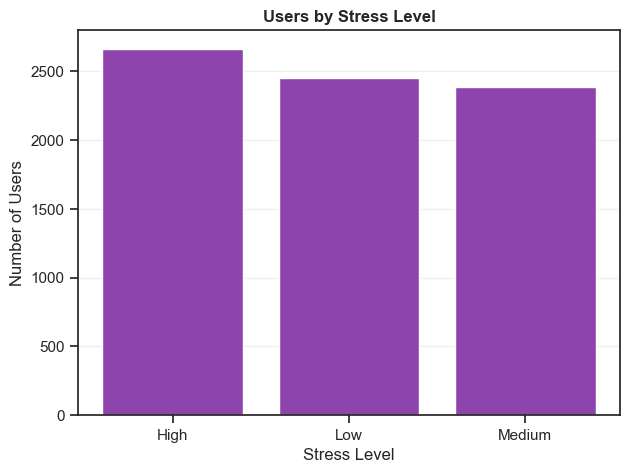

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(df["stress_level"],
        df["TotalUsers"],
        color="#8E44AD")

plt.title("Users by Stress Level", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 9. Average App Opens by Addiction Level

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT addiction_level,
ROUND(AVG(app_opens_per_day),2) AS AvgOpens
FROM smart
GROUP BY addiction_level;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

  addiction_level  AvgOpens
0            Mild        96
1          Severe        98
2        Moderate        97
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


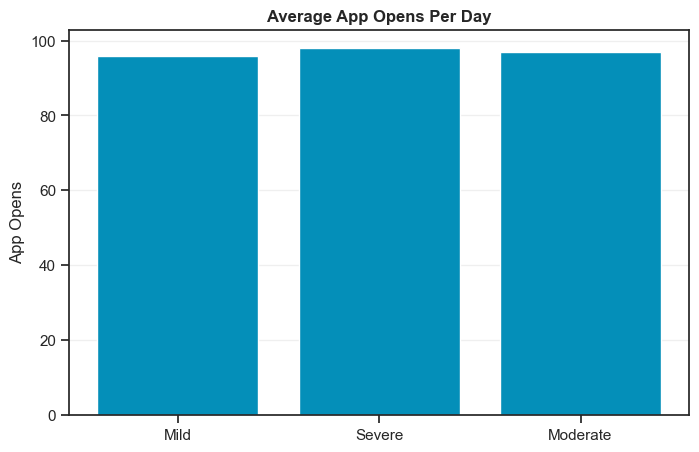

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["addiction_level"],
        df["AvgOpens"],
        color="#048FB9")

plt.title("Average App Opens Per Day",fontweight='bold')
plt.ylabel("App Opens")
plt.grid(axis='y',alpha=.3)
plt.show()

## 10. Weekend Screen Time by Addiction Level

In [ ]:
conn = connect_to_sql_server()


query = """
SELECT addiction_level,
ROUND(AVG(weekend_screen_time),2) AS AvgWeekend
FROM smart
GROUP BY addiction_level;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)

  addiction_level  AvgWeekend
0            Mild        6.89
1          Severe       10.36
2        Moderate       10.09
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


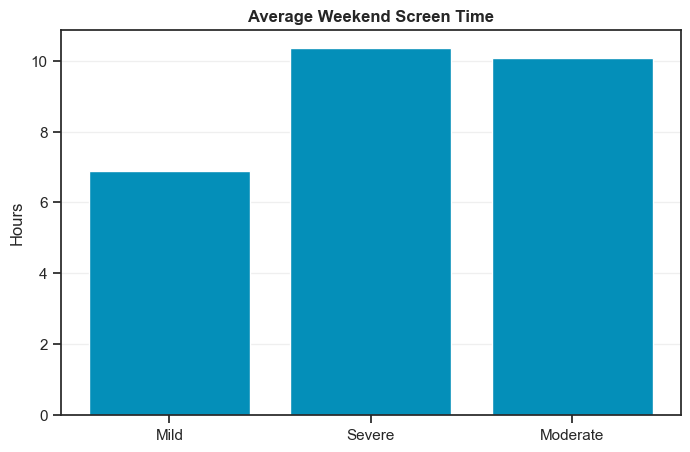

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["addiction_level"],
        df["AvgWeekend"],
        color="#048FB9")

plt.title("Average Weekend Screen Time",fontweight='bold')
plt.ylabel("Hours")
plt.grid(axis='y',alpha=.3)
plt.show()

## 11. Smartphone Addiction Risk (%) by Age Group


In [ ]:
conn = connect_to_sql_server()


query = """
SELECT
    CASE
        WHEN age <= 19 THEN 'Teen (<=19)'
        WHEN age BETWEEN 20 AND 25 THEN 'Young Adult (20-25)'
        WHEN age BETWEEN 26 AND 40 THEN 'Adult (26-40)'
        ELSE 'Senior (40+)'
    END AS age_group,
    ROUND(AVG(CAST(addicted_label AS FLOAT)) * 100, 1) AS AddictionRiskPct
FROM smart
GROUP BY
    CASE
        WHEN age <= 19 THEN 'Teen (<=19)'
        WHEN age BETWEEN 20 AND 25 THEN 'Young Adult (20-25)'
        WHEN age BETWEEN 26 AND 40 THEN 'Adult (26-40)'
        ELSE 'Senior (40+)'
    END;
    """   
    
    
df = read_data_from_sql(conn, query)

if df is not None:
    
    
    print(df.head(55))   
else:
    print("NOT FOUND")


close_connection(conn)


             age_group  AddictionRiskPct
0          Teen (<=19)              69.1
1         Senior (40+)             100.0
2        Adult (26-40)              71.0
3  Young Adult (20-25)              70.9
تم إغلاق الاتصال بنجاح.


C:\Users\jana3\AppData\Local\Temp\ipykernel_47912\1862534840.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


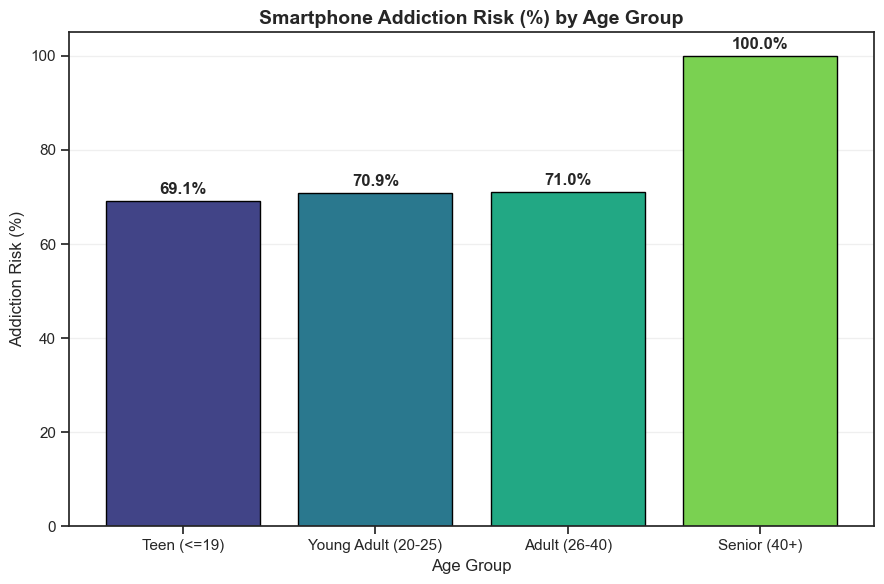

In [ ]:
age_order = ['Teen (<=19)', 'Young Adult (20-25)', 'Adult (26-40)', 'Senior (40+)']
df = df.set_index("age_group").reindex(age_order).reset_index()

plt.figure(figsize=(9,6))
colors = sns.color_palette("viridis", len(df))
bars = plt.bar(df["age_group"], df["AddictionRiskPct"], color=colors, edgecolor="black")

for bar, val in zip(bars, df["AddictionRiskPct"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val}%", ha="center", fontweight="bold")

plt.title("Smartphone Addiction Risk (%) by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Addiction Risk (%)")
plt.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()


In [33]:
df_fe.to_csv("Data.csv")